In [1]:
import pandas as pd
#los datos proceden de una biblioteca del curso MOOC de ML de la UGR
gene_exp_inmune=pd.read_csv('https://drive.google.com/uc?id=1PYzEIdmnfjOnBpPDIFBE9hL1Lkj_OBCk', index_col=0)
clinical_info_inmune=pd.read_csv('https://drive.google.com/uc?id=1hHQfcvrFa5Jds-9tW_X4sHjKpYKdii9s', index_col=0)
X, y = gene_exp_inmune, clinical_info_inmune
X.head() #Me sirve para comprobar que se han cargado los datos correctamente

,COL2A1,RXRG,CCL19,SSX1,CST2,PRSS33,CDH2,SCUBE2,TMPRSS13,TRPM8,...,UBASH3A,GBP4,PRF1,PTK6,PCDHB2,GSDMA,DIO2,PLIN1,NCF1C,SLC7A11
0,-1.431141,-7.845756,0.665118,-1.409304,-2.537396,-1.676281,1.529957,-0.895042,-0.298778,5.091742,...,-0.659997,-1.469602,-0.570793,1.047635,-2.068966,-0.202828,-0.506767,1.285256,-0.901222,2.483020
1,-0.424374,-8.352423,0.386055,-2.846138,-0.685105,0.339787,-3.488043,-0.584982,5.679815,-1.117879,...,0.190202,-0.282190,0.375094,0.261662,3.356282,2.028145,-2.399010,-1.152801,0.662490,-2.914991
2,11.014251,0.415549,-1.633781,0.315442,-0.662332,-0.498761,0.535811,-0.467456,-2.818738,1.731049,...,-0.816305,-0.316202,-1.153745,-2.284201,-1.761597,-0.746975,-2.988195,-1.976877,-1.400889,-2.266779
3,-1.180446,-8.187415,-1.958023,5.061146,-2.603744,-0.666706,0.456460,-4.609624,-1.713164,-3.880876,...,0.214344,-0.327110,0.476764,1.153275,-0.337649,-1.006765,-2.686648,-1.329148,0.055994,-2.652313
4,0.816312,-1.189303,4.837235,4.972176,-2.963715,-2.665721,-0.268042,-1.740607,0.011610,-4.107467,...,3.352734,2.145368,3.358865,-2.324389,-1.741669,0.734312,-1.649316,6.284688,1.450729,1.131275


In [2]:
#Transformar el problema en uno de dos dimensiones
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
n_componentes = 2
pca=PCA(n_components=n_componentes)
#Visualizar el problema en dos dimensiones
X_2D=pca.fit_transform(X)
st=StandardScaler()
X_2D=st.fit_transform(X_2D)

In [3]:
#Validación Hold-out
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
y_int = pd.get_dummies(y).iloc[:,0]
X_2D_train, X_2D_test, y_int_train, y_int_test = train_test_split(X_2D, y_int, random_state=42)
print("Número de instancias en el conjunto de entrenamiento: {}; y test: {}".format(len(X_train), len(X_test)))

Número de instancias en el conjunto de entrenamiento: 252; y test: 84


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train.squeeze())
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Porcentaje de acierto: {:.2f}%".format(acc*100))

Porcentaje de acierto: 91.67%


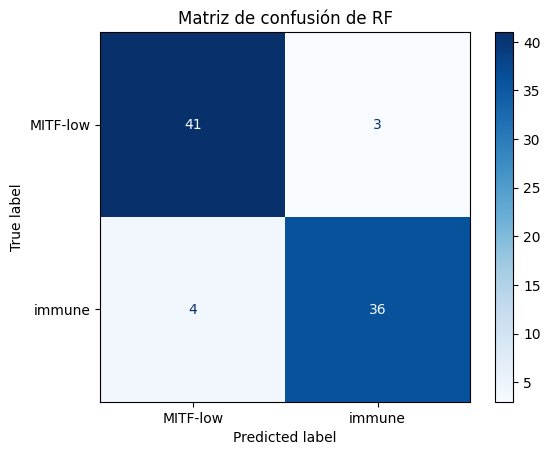

              precision    recall  f1-score   support

    MITF-low       0.91      0.93      0.92        44
      immune       0.92      0.90      0.91        40

    accuracy                           0.92        84
   macro avg       0.92      0.92      0.92        84
weighted avg       0.92      0.92      0.92        84

F1-score para RF: 0.91
AUC para RF: 0.97


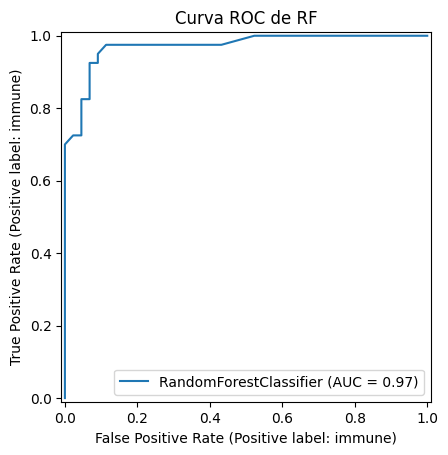

In [5]:
#Métricas de evaluación
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

metrics.ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap="Blues")
plt.title("Matriz de confusión de RF")
plt.show()

print(metrics.classification_report(y_test, y_pred))

f1 = metrics.f1_score(y_test, y_pred, pos_label='immune')
print("F1-score para RF: {:.2f}".format(f1))

y_probs = rf.predict_proba(X_test)
auc = metrics.roc_auc_score(y_test, y_probs[:, 1])
print("AUC para RF: {:.2f}".format(auc))
metrics.RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Curva ROC de RF")
plt.show()



Características origniales: 50, Características seleccionadas: 25
Porcentaje de acierto con características seleccionadas: 91.67%


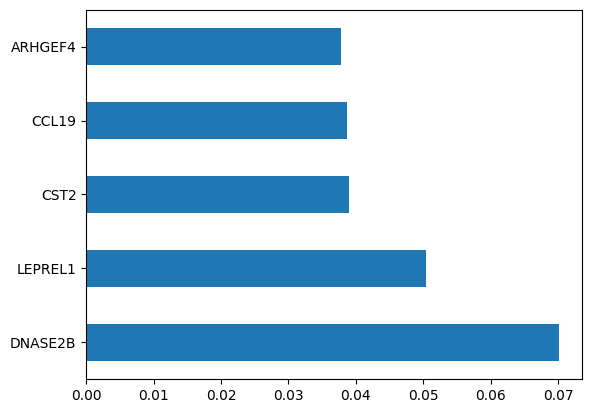

In [6]:
#Selección de características y ranking de importancia
from sklearn.feature_selection import SelectFromModel

importancia = rf.feature_importances_
pd.Series(importancia, index=X_train.columns).nlargest(5).plot(kind='barh')

#Se transforma el conjunto de entrenamiento y test con las características seleccionadas
fs = SelectFromModel(rf, prefit=True, threshold='median') #Seleccionamos las características con importancia mayor a la mediana
selected_mask = fs.get_support()    #Usar get_support en vez de transform para no perder nombres de columnas
X_train_fs = X_train.loc[:, selected_mask]
X_test_fs = X_test.loc[:, selected_mask]
print(f"\nCaracterísticas origniales: {X_train.shape[1]}, Características seleccionadas: {X_train_fs.shape[1]}")

rf_fs = RandomForestClassifier(random_state=42) #Reentrenamos el modelo con las características seleccionadas
rf_fs.fit(X_train_fs, y_train.squeeze())

y_pred_fs = rf_fs.predict(X_test_fs)
acc_fs = accuracy_score(y_test, y_pred_fs)
print("Porcentaje de acierto con características seleccionadas: {:.2f}%".format(acc_fs*100))

In [7]:
#Comparación de diferentes umbrales de selección de características
#Esto me permite ver cómo varía la precisión del modelo al variar el número de genes seleccionados
#Por este motivo, en la linea de código anterior se ha seleccionado 'median' como umbral,
#presentando un número razonable de genes y la mejor precisión.
for threshold in ["mean", "median", "0.5*mean"]:
    fs_tmp = SelectFromModel(rf, prefit=True, threshold=threshold)
    selected_mask = fs_tmp.get_support()
    X_tr = X_train.loc[:, selected_mask]
    X_te = X_test.loc[:, selected_mask]
    rf_tmp = RandomForestClassifier(random_state=42)
    rf_tmp.fit(X_tr, y_train.values.ravel())
    acc_tmp = accuracy_score(y_test.values.ravel(), rf_tmp.predict(X_te))
    print(f"threshold='{threshold}': {selected_mask.sum()} genes → accuracy={acc_tmp*100:.2f}%")

threshold='mean': 16 genes → accuracy=88.10%
threshold='median': 25 genes → accuracy=91.67%
threshold='0.5*mean': 43 genes → accuracy=89.29%


<Figure size 1000x700 with 0 Axes>

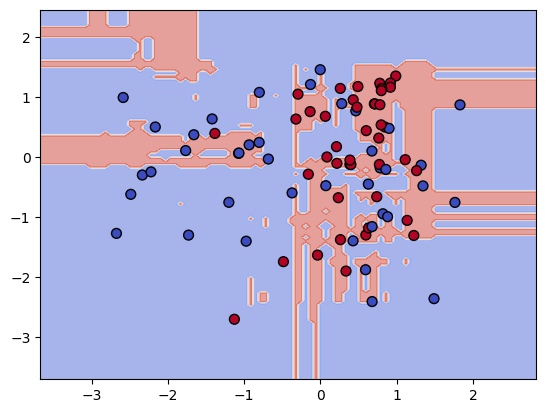

In [8]:
#Crear y entrenar el modelo 2D
from sklearn.inspection import DecisionBoundaryDisplay

clf = RandomForestClassifier(random_state=42)   
clf.fit(X_2D_train, y_int_train)
score = clf.score(X_2D_test, y_int_test)
fig = plt.figure(figsize=(10, 7))
fig = DecisionBoundaryDisplay.from_estimator(clf, X_2D_test, 
                                             response_method='predict',
                                             alpha=0.5,cmap='coolwarm')
fig.ax_.scatter(X_2D_test[:, 0], X_2D_test[:, 1],
                c=y_int_test, edgecolor='k',
                s=50, cmap='coolwarm')
plt.show()

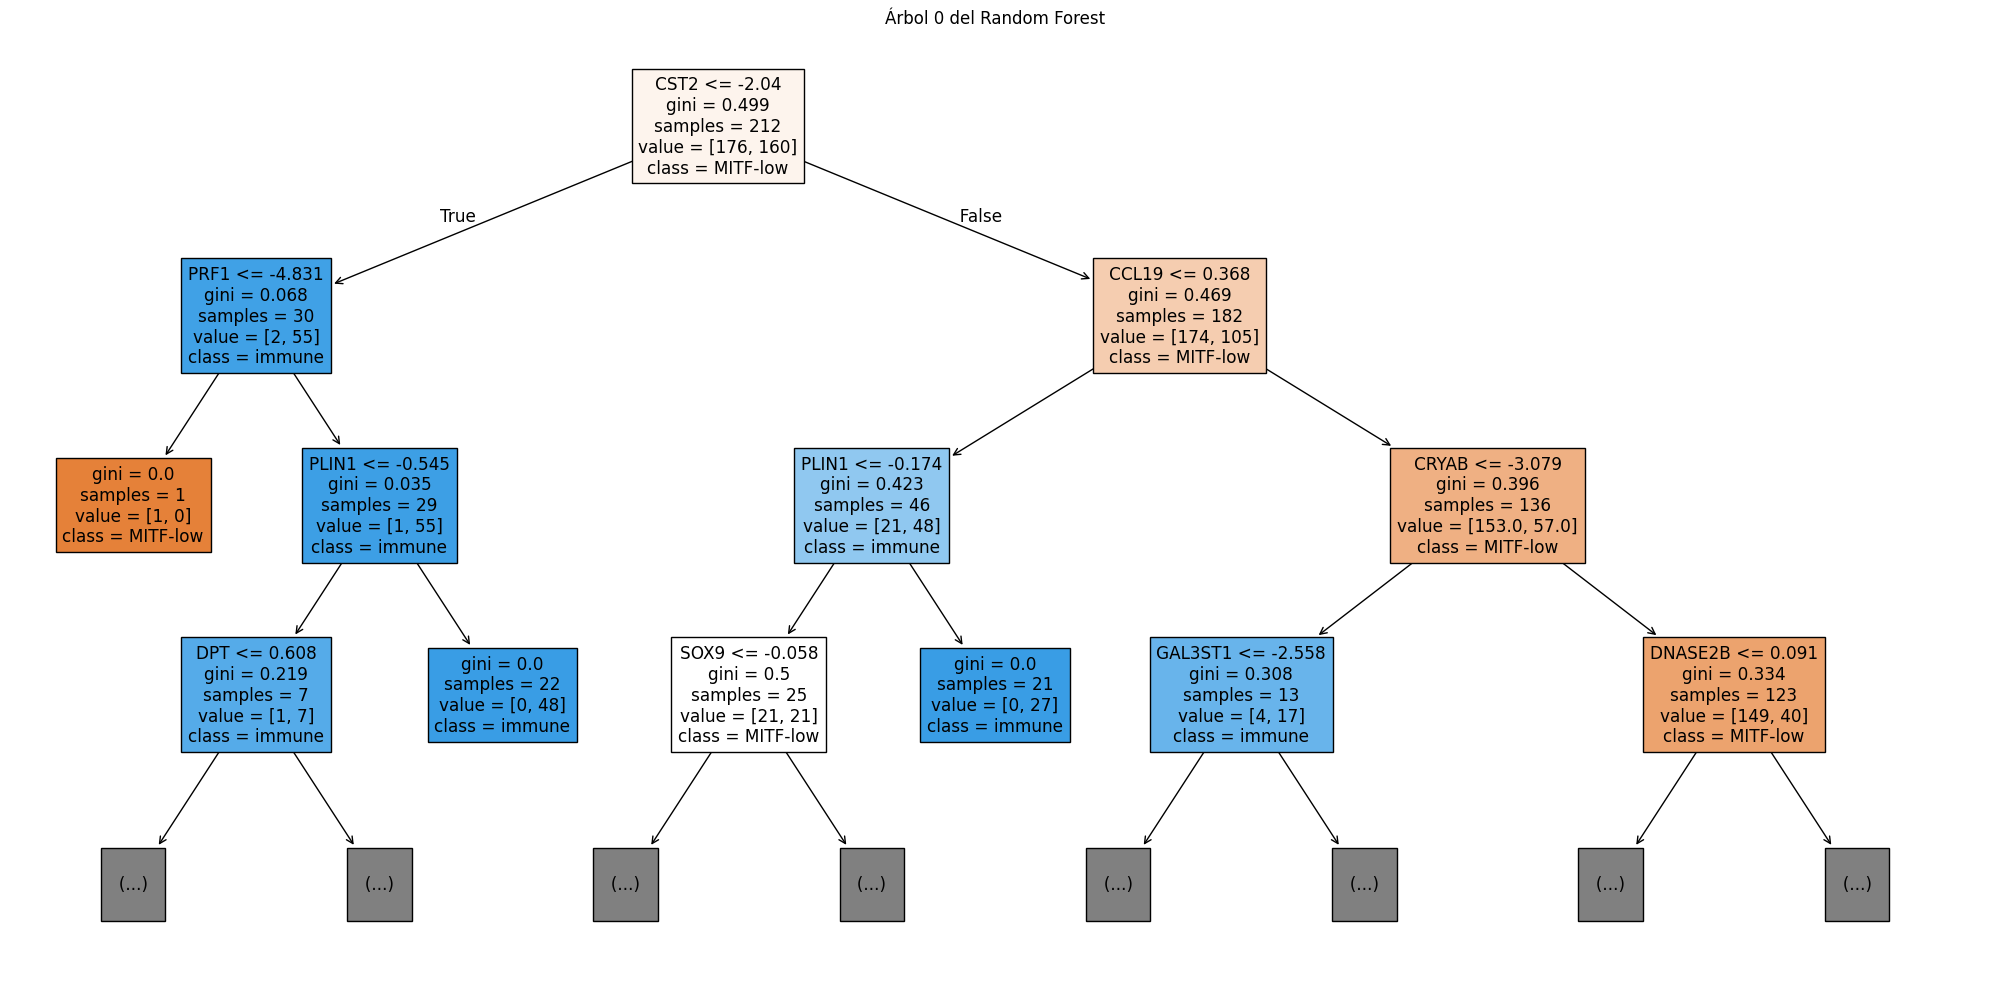

In [9]:
#Visualizar uno de los árboles contenidos dentro del Random Forest
from sklearn import tree
import matplotlib.pyplot as plt

rf_full = RandomForestClassifier(random_state=42)
rf_full.fit(X, y.values.ravel())
dt = rf_full.estimators_[0]

plt.figure(figsize=(20, 10))
tree.plot_tree(dt,
               feature_names=X.columns,
               class_names=rf_full.classes_,
               filled=True,
               max_depth=3)  # sin max_depth el árbol es ilegible
plt.title("Árbol 0 del Random Forest")
plt.tight_layout()
plt.show()

In [10]:
#Vamos a hacer una validación cruzada para comprobar que el split no es suerte
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_fs, X_train_fs, y_train.squeeze(),
                         cv=cv, scoring='accuracy')

print("Accuracy por fold:", ["{:.2f}%".format(s*100) for s in scores])
print(f"Accuracy media: {scores.mean()*100:.2f}%")
print(f"Deviación típica: {scores.std()*100:.2f}%")
print(f"Intervalo 95%: [{(scores.mean()-2*scores.std())*100:.2f}%, {(scores.mean()+2*scores.std())*100:.2f}%]")

Accuracy por fold: ['88.24%', '92.16%', '92.00%', '82.00%', '92.00%']
Accuracy media: 89.28%
Deviación típica: 3.93%
Intervalo 95%: [81.42%, 97.14%]


La media del Accuracy por fold es de 89,28% frente al hold-out 91,67%. Esto quiere decri que el Hold-out era ligeramente optimista con el modelo, pero el rendimiento sigue siendo bueno.
La desviación estándar está por debajo del 5% lo que es buen indicio.
Un fold, 82.00% es un outlier, que podemos intentar investigar

In [11]:
#Vamos a continuar con GridSearch para intentar mejorar el 89.28% y estabilizar el fold 4.
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100, 200],
              'max_depth': [None, 5, 10],
              'min_samples_split': [2, 5],
              'min_samples_leaf': [1,2]
              }

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,                    # reutilizamos el StratifiedKFold de antes
    scoring='accuracy',
    n_jobs=-1,                # usa todos los núcleos del procesador
    verbose=1                 # muestra progreso
)
grid_search.fit(X_train_fs, y_train.squeeze())
print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"Mejor accuracy en CV: {grid_search.best_score_*100:.2f}%")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores hiperparámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Mejor accuracy en CV: 90.09%


teniendo 25 características bien definidas, el n_estimators no tiene que ser 100, con 50 es suficiente.
Además, el modelo se beneficia de limitar la profundidad, max_depth=10. Esto confirma que hay algo de overfitting con árboles sin restricción- 

In [14]:
#Optimizamos el modelo y reentrenamos con los mejores parámetros
rf_optimized = grid_search.best_estimator_

y_pred_opt = rf_optimized.predict(X_test_fs)
acc_opt = accuracy_score(y_test.squeeze(), y_pred_opt)
print(f"Accuracy en test (optimizado): {acc_opt*100:.2f}%")

#Comparativa completa
print("\n--- Resumen comparativo ---")
print(f"RF original (hold-out):           91.67%")
print(f"RF features seleccionadas (CV):   89.28%")
print(f"RF optimizado (CV):               90.09%")
print(f"RF optimizado (test):             {acc_opt*100:.2f}%")

Accuracy en test (optimizado): 91.67%

--- Resumen comparativo ---
RF original (hold-out):           91.67%
RF features seleccionadas (CV):   89.28%
RF optimizado (CV):               90.09%
RF optimizado (test):             91.67%


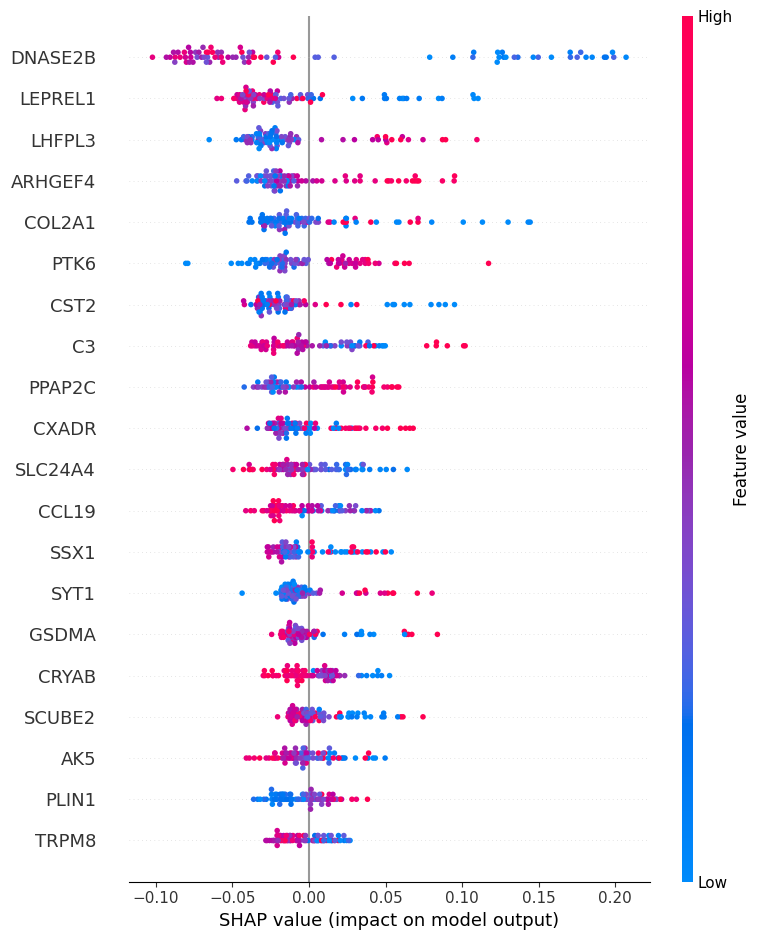

In [18]:
#Vamos a usar SHAP para ver qué genes concretos impulsan las predicciones y en qué dirección
import shap
explainer=shap.TreeExplainer(rf_optimized)
shap_values=explainer.shap_values(X_test_fs)

#Beeswarm; importancia y direcciión del efecto
shap.summary_plot(shap_values[:,:,1],
                  X_test_fs,
                  feature_names=X_train_fs.columns.tolist())


Gracias al gráfico Beeswarm podemos observar patrones dentro de cada gen. Por ejemplo, DNASE2B y LEPREL1 ambos presentan alta expresión (color rojo) 'MITF-low' y baja expresión (color azul) 'immune'. Además, hay una gran dispersión horizontal, lo que implica un gran impacto en las muestras. 
Por otro lado, ARHGEF4 y PTK& también presentan gran dispersión, demostrando la importancia de estos genes, pero el patrón de colores es invertido, por lo que hay gran expresión hacia 'immune' y baja en 'MITF-low'